# 1. Install Library

In [1]:
!pip install pandas
!pip install numpy
!pip install matplotlib
!pip install seaborn
!pip install nltk
!pip install sastrawi
!pip install wordcloud
!pip install scikit-learn
!pip install joblib
!pip install tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 6.1 MB/s eta 0:00:00


Tahap ini digunakan untuk menginstal seluruh library yang dibutuhkan dalam proses analisis sentimen. Library **pandas** digunakan untuk pengolahan data tabular, **numpy** untuk komputasi numerik, **matplotlib** dan seaborn untuk visualisasi data, **nltk** dan **sastrawi** untuk pemrosesan bahasa alami (Natural Language Processing), **wordcloud** untuk visualisasi kata yang sering muncul, scikit-learn untuk pembangunan model machine learning, **joblib** untuk menyimpan model yang telah dilatih, dan **tqdm** untuk menampilkan progress bar selama proses preprocessing.




# 2. Import Library

In [2]:
import pandas as pd
import numpy as np

import re
import string
import warnings

warnings.filterwarnings("ignore")

Tahap ini bertujuan untuk mengimpor library yang akan digunakan selama proses penelitian. Library **re** digunakan untuk membersihkan teks menggunakan regular expression, sedangkan **warnings** digunakan untuk menyembunyikan pesan peringatan yang tidak memengaruhi proses analisis.

# 3. Import Library NLP

In [3]:
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

Library **NLTK** digunakan untuk melakukan tokenisasi dan menghapus stopword. **Tokenisasi** merupakan proses memecah kalimat menjadi kata-kata individual. Sementara itu, **Sastrawi** digunakan untuk proses stemming, yaitu mengubah kata menjadi bentuk dasarnya.

# 4.Download Resource NLTK

In [4]:
import nltk

nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

Dataset NLTK yang diperlukan harus diunduh terlebih dahulu. Dataset **punkt** digunakan untuk tokenisasi, sedangkan dataset **stopwords** digunakan untuk menghapus kata-kata yang tidak memiliki makna penting dalam analisis sentimen.

# 5. Membaca Dataset

In [14]:
df = pd.read_csv('Label_pajak.csv')
df.head()
df.tail()

,content,sentiment
7312,Mudah bgt sekarang,1
7313,Waw keren,1
7314,"Mantab, ini yg resmi ya ?",1
7315,Buat billing jadi lebih mudah 😍 semoga fitur f...,1
7316,Cakepp,1


Dataset yang telah diberi label dibaca menggunakan fungsi read_csv(). Dataset terdiri dari dua atribut utama:

| Kolom     | Keterangan           |
| --------- | -------------------- |
| content   | Teks ulasan pengguna |
| sentiment | Label sentimen       |


# 6. Menampilkan Informasi Dataset

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7317 entries, 0 to 7316
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   content    7317 non-null   object
 1   sentiment  7317 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 114.5+ KB


# 7. Visualisasi Distribusi Sentimen

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

<Axes: xlabel='sentiment', ylabel='count'>

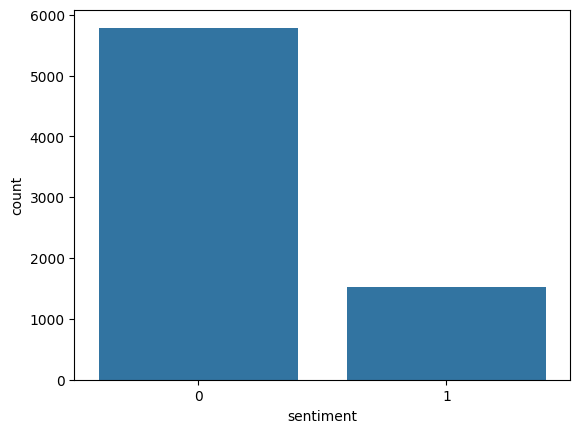

In [17]:
sns.countplot(
    x='sentiment',
    data=df
)

Untuk mengetahui jumlah masing-masing label (0 dan 1)

In [18]:
df['sentiment'].value_counts()

,count
sentiment,
0,5788
1,1529


# 8. Membuat Kamus Slangword

In [19]:
# Mendefinisikan fungsi untuk slangwords

slangwords = {"@": "di", "abis": "habis", "wtb": "beli", "masi": "masih", "wts": "jual", "wtt": "tukar", "bgt": "banget", "maks": "maksimal", "plisss": "tolong", "bgttt": "banget", "indo": "indonesia", "bgtt": "banget", "ad": "ada", "rv": "redvelvet", "plis": "tolong", "pls": "tolong", "cr": "sumber", "cod": "bayar ditempat", "adlh": "adalah", "afaik": "as far as i know", "ahaha": "haha", "aj": "saja", "ajep-ajep": "dunia gemerlap", "ak": "saya", "akika": "aku", "akkoh": "aku", "akuwh": "aku", "alay": "norak", "alow": "halo", "ambilin": "ambilkan", "ancur": "hancur", "anjrit": "anjing", "anter": "antar", "ap2": "apa-apa", "apasih": "apa sih", "apes": "sial", "aps": "apa", "aq": "saya", "aquwh": "aku", "asbun": "asal bunyi", "aseekk": "asyik", "asekk": "asyik", "asem": "asam", "aspal": "asli tetapi palsu", "astul": "asal tulis", "ato": "atau", "au ah": "tidak mau tahu", "awak": "saya", "ay": "sayang", "ayank": "sayang", "b4": "sebelum", "bakalan": "akan", "bandes": "bantuan desa", "bangedh": "banget", "banpol": "bantuan polisi", "banpur": "bantuan tempur", "basbang": "basi", "bcanda": "bercanda", "bdg": "bandung", "begajulan": "nakal", "beliin": "belikan", "bencong": "banci", "bentar": "sebentar", "ber3": "bertiga", "beresin": "membereskan", "bete": "bosan", "beud": "banget", "bg": "abang", "bgmn": "bagaimana", "bgt": "banget", "bijimane": "bagaimana", "bintal": "bimbingan mental", "bkl": "akan", "bknnya": "bukannya", "blegug": "bodoh", "blh": "boleh", "bln": "bulan", "blum": "belum", "bnci": "benci", "bnran": "yang benar", "bodor": "lucu", "bokap": "ayah", "boker": "buang air besar", "bokis": "bohong", "boljug": "boleh juga", "bonek": "bocah nekat", "boyeh": "boleh", "br": "baru", "brg": "bareng", "bro": "saudara laki-laki", "bru": "baru", "bs": "bisa", "bsen": "bosan", "bt": "buat", "btw": "ngomong-ngomong", "buaya": "tidak setia", "bubbu": "tidur", "bubu": "tidur", "bumil": "ibu hamil", "bw": "bawa", "bwt": "buat", "byk": "banyak", "byrin": "bayarkan", "cabal": "sabar", "cadas": "keren", "calo": "makelar", "can": "belum", "capcus": "pergi", "caper": "cari perhatian", "ce": "cewek", "cekal": "cegah tangkal", "cemen": "penakut", "cengengesan": "tertawa", "cepet": "cepat", "cew": "cewek", "chuyunk": "sayang", "cimeng": "ganja", "cipika cipiki": "cium pipi kanan cium pipi kiri", "ciyh": "sih", "ckepp": "cakep", "ckp": "cakep", "cmiiw": "correct me if i'm wrong", "cmpur": "campur", "cong": "banci", "conlok": "cinta lokasi", "cowwyy": "maaf", "cp": "siapa", "cpe": "capek", "cppe": "capek", "cucok": "cocok", "cuex": "cuek", "cumi": "Cuma miscall", "cups": "culun", "curanmor": "pencurian kendaraan bermotor", "curcol": "curahan hati colongan", "cwek": "cewek", "cyin": "cinta", "d": "di", "dah": "deh", "dapet": "dapat", "de": "adik", "dek": "adik", "demen": "suka", "deyh": "deh", "dgn": "dengan", "diancurin": "dihancurkan", "dimaafin": "dimaafkan", "dimintak": "diminta", "disono": "di sana", "dket": "dekat", "dkk": "dan kawan-kawan", "dll": "dan lain-lain", "dlu": "dulu", "dngn": "dengan", "dodol": "bodoh", "doku": "uang", "dongs": "dong", "dpt": "dapat", "dri": "dari", "drmn": "darimana", "drtd": "dari tadi", "dst": "dan seterusnya", "dtg": "datang", "duh": "aduh", "duren": "durian", "ed": "edisi", "egp": "emang gue pikirin", "eke": "aku", "elu": "kamu", "emangnya": "memangnya", "emng": "memang", "endak": "tidak", "enggak": "tidak", "envy": "iri", "ex": "mantan", "fax": "facsimile", "fifo": "first in first out", "folbek": "follow back", "fyi": "sebagai informasi", "gaada": "tidak ada uang", "gag": "tidak", "gaje": "tidak jelas", "gak papa": "tidak apa-apa", "gan": "juragan", "gaptek": "gagap teknologi", "gatek": "gagap teknologi", "gawe": "kerja", "gbs": "tidak bisa", "gebetan": "orang yang disuka", "geje": "tidak jelas", "gepeng": "gelandangan dan pengemis", "ghiy": "lagi", "gile": "gila", "gimana": "bagaimana", "gino": "gigi nongol", "githu": "gitu", "gj": "tidak jelas", "gmana": "bagaimana", "gn": "begini", "goblok": "bodoh", "golput": "golongan putih", "gowes": "mengayuh sepeda", "gpny": "tidak punya", "gr": "gede rasa", "gretongan": "gratisan", "gtau": "tidak tahu", "gua": "saya", "guoblok": "goblok", "gw": "saya", "ha": "tertawa", "haha": "tertawa", "hallow": "halo", "hankam": "pertahanan dan keamanan", "hehe": "he", "helo": "halo", "hey": "hai", "hlm": "halaman", "hny": "hanya", "hoax": "isu bohong", "hr": "hari", "hrus": "harus", "hubdar": "perhubungan darat", "huff": "mengeluh", "hum": "rumah", "humz": "rumah", "ilang": "hilang", "ilfil": "tidak suka", "imho": "in my humble opinion", "imoetz": "imut", "item": "hitam", "itungan": "hitungan", "iye": "iya", "ja": "saja", "jadiin": "jadi", "jaim": "jaga image", "jayus": "tidak lucu", "jdi": "jadi", "jem": "jam", "jga": "juga", "jgnkan": "jangankan", "jir": "anjing", "jln": "jalan", "jomblo": "tidak punya pacar", "jubir": "juru bicara", "jutek": "galak", "k": "ke", "kab": "kabupaten", "kabor": "kabur", "kacrut": "kacau", "kadiv": "kepala divisi", "kagak": "tidak", "kalo": "kalau", "kampret": "sialan", "kamtibmas": "keamanan dan ketertiban masyarakat", "kamuwh": "kamu", "kanwil": "kantor wilayah", "karna": "karena", "kasubbag": "kepala subbagian", "katrok": "kampungan", "kayanya": "kayaknya", "kbr": "kabar", "kdu": "harus", "kec": "kecamatan", "kejurnas": "kejuaraan nasional", "kekeuh": "keras kepala", "kel": "kelurahan", "kemaren": "kemarin", "kepengen": "mau", "kepingin": "mau", "kepsek": "kepala sekolah", "kesbang": "kesatuan bangsa", "kesra": "kesejahteraan rakyat", "ketrima": "diterima", "kgiatan": "kegiatan", "kibul": "bohong", "kimpoi": "kawin", "kl": "kalau", "klianz": "kalian", "kloter": "kelompok terbang", "klw": "kalau", "km": "kamu", "kmps": "kampus", "kmrn": "kemarin", "knal": "kenal", "knp": "kenapa", "kodya": "kota madya", "komdis": "komisi disiplin", "komsov": "komunis sovyet", "kongkow": "kumpul bareng teman-teman", "kopdar": "kopi darat", "korup": "korupsi", "kpn": "kapan", "krenz": "keren", "krm": "kirim", "kt": "kita", "ktmu": "ketemu", "ktr": "kantor", "kuper": "kurang pergaulan", "kw": "imitasi", "kyk": "seperti", "la": "lah", "lam": "salam", "lamp": "lampiran", "lanud": "landasan udara", "latgab": "latihan gabungan", "lebay": "berlebihan", "leh": "boleh", "lelet": "lambat", "lemot": "lambat", "lgi": "lagi", "lgsg": "langsung", "liat": "lihat", "litbang": "penelitian dan pengembangan", "lmyn": "lumayan", "lo": "kamu", "loe": "kamu", "lola": "lambat berfikir", "louph": "cinta", "low": "kalau", "lp": "lupa", "luber": "langsung, umum, bebas, dan rahasia", "luchuw": "lucu", "lum": "belum", "luthu": "lucu", "lwn": "lawan", "maacih": "terima kasih", "mabal": "bolos", "macem": "macam", "macih": "masih", "maem": "makan", "magabut": "makan gaji buta", "maho": "homo", "mak jang": "kaget", "maksain": "memaksa", "malem": "malam", "mam": "makan", "maneh": "kamu", "maniez": "manis", "mao": "mau", "masukin": "masukkan", "melu": "ikut", "mepet": "dekat sekali", "mgu": "minggu", "migas": "minyak dan gas bumi", "mikol": "minuman beralkohol", "miras": "minuman keras", "mlah": "malah", "mngkn": "mungkin", "mo": "mau", "mokad": "mati", "moso": "masa", "mpe": "sampai", "msk": "masuk", "mslh": "masalah", "mt": "makan teman", "mubes": "musyawarah besar", "mulu": "melulu", "mumpung": "selagi", "munas": "musyawarah nasional", "muntaber": "muntah dan berak", "musti": "mesti", "muupz": "maaf", "mw": "now watching", "n": "dan", "nanam": "menanam", "nanya": "bertanya", "napa": "kenapa", "napi": "narapidana", "napza": "narkotika, alkohol, psikotropika, dan zat adiktif ", "narkoba": "narkotika, psikotropika, dan obat terlarang", "nasgor": "nasi goreng", "nda": "tidak", "ndiri": "sendiri", "ne": "ini", "nekolin": "neokolonialisme", "nembak": "menyatakan cinta", "ngabuburit": "menunggu berbuka puasa", "ngaku": "mengaku", "ngambil": "mengambil", "nganggur": "tidak punya pekerjaan", "ngapah": "kenapa", "ngaret": "terlambat", "ngasih": "memberikan", "ngebandel": "berbuat bandel", "ngegosip": "bergosip", "ngeklaim": "mengklaim", "ngeksis": "menjadi eksis", "ngeles": "berkilah", "ngelidur": "menggigau", "ngerampok": "merampok", "ngga": "tidak", "ngibul": "berbohong", "ngiler": "mau", "ngiri": "iri", "ngisiin": "mengisikan", "ngmng": "bicara", "ngomong": "bicara", "ngubek2": "mencari-cari", "ngurus": "mengurus", "nie": "ini", "nih": "ini", "niyh": "nih", "nmr": "nomor", "nntn": "nonton", "nobar": "nonton bareng", "np": "now playing", "ntar": "nanti", "ntn": "nonton", "numpuk": "bertumpuk", "nutupin": "menutupi", "nyari": "mencari", "nyekar": "menyekar", "nyicil": "mencicil", "nyoblos": "mencoblos", "nyokap": "ibu", "ogah": "tidak mau", "ol": "online", "ongkir": "ongkos kirim", "oot": "out of topic", "org2": "orang-orang", "ortu": "orang tua", "otda": "otonomi daerah", "otw": "on the way, sedang di jalan", "pacal": "pacar", "pake": "pakai", "pala": "kepala", "pansus": "panitia khusus", "parpol": "partai politik", "pasutri": "pasangan suami istri", "pd": "pada", "pede": "percaya diri", "pelatnas": "pemusatan latihan nasional", "pemda": "pemerintah daerah", "pemkot": "pemerintah kota", "pemred": "pemimpin redaksi", "penjas": "pendidikan jasmani", "perda": "peraturan daerah", "perhatiin": "perhatikan", "pesenan": "pesanan", "pgang": "pegang", "pi": "tapi", "pilkada": "pemilihan kepala daerah", "pisan": "sangat", "pk": "penjahat kelamin", "plg": "paling", "pmrnth": "pemerintah", "polantas": "polisi lalu lintas", "ponpes": "pondok pesantren", "pp": "pulang pergi", "prg": "pergi", "prnh": "pernah", "psen": "pesan", "pst": "pasti", "pswt": "pesawat", "pw": "posisi nyaman", "qmu": "kamu", "rakor": "rapat koordinasi", "ranmor": "kendaraan bermotor", "re": "reply", "ref": "referensi", "rehab": "rehabilitasi", "rempong": "sulit", "repp": "balas", "restik": "reserse narkotika", "rhs": "rahasia", "rmh": "rumah", "ru": "baru", "ruko": "rumah toko", "rusunawa": "rumah susun sewa", "ruz": "terus", "saia": "saya", "salting": "salah tingkah", "sampe": "sampai", "samsek": "sama sekali", "sapose": "siapa", "satpam": "satuan pengamanan", "sbb": "sebagai berikut", "sbh": "sebuah", "sbnrny": "sebenarnya", "scr": "secara", "sdgkn": "sedangkan", "sdkt": "sedikit", "se7": "setuju", "sebelas dua belas": "mirip", "sembako": "sembilan bahan pokok", "sempet": "sempat", "sendratari": "seni drama tari", "sgt": "sangat", "shg": "sehingga", "siech": "sih", "sikon": "situasi dan kondisi", "sinetron": "sinema elektronik", "siramin": "siramkan", "sj": "saja", "skalian": "sekalian", "sklh": "sekolah", "skt": "sakit", "slesai": "selesai", "sll": "selalu", "slma": "selama", "slsai": "selesai", "smpt": "sempat", "smw": "semua", "sndiri": "sendiri", "soljum": "sholat jumat", "songong": "sombong", "sory": "maaf", "sosek": "sosial-ekonomi", "sotoy": "sok tahu", "spa": "siapa", "sppa": "siapa", "spt": "seperti", "srtfkt": "sertifikat", "stiap": "setiap", "stlh": "setelah", "suk": "masuk", "sumpek": "sempit", "syg": "sayang", "t4": "tempat", "tajir": "kaya", "tau": "tahu", "taw": "tahu", "td": "tadi", "tdk": "tidak", "teh": "kakak perempuan", "telat": "terlambat", "telmi": "telat berpikir", "temen": "teman", "tengil": "menyebalkan", "tepar": "terkapar", "tggu": "tunggu", "tgu": "tunggu", "thankz": "terima kasih", "thn": "tahun", "tilang": "bukti pelanggaran", "tipiwan": "TvOne", "tks": "terima kasih", "tlp": "telepon", "tls": "tulis", "tmbah": "tambah", "tmen2": "teman-teman", "tmpah": "tumpah", "tmpt": "tempat", "tngu": "tunggu", "tnyta": "ternyata", "tokai": "tai", "toserba": "toko serba ada", "tpi": "tapi", "trdhulu": "terdahulu", "trima": "terima kasih", "trm": "terima", "trs": "terus", "trutama": "terutama", "ts": "penulis", "tst": "tahu sama tahu", "ttg": "tentang", "tuch": "tuh", "tuir": "tua", "tw": "tahu", "u": "kamu", "ud": "sudah", "udah": "sudah", "ujg": "ujung", "ul": "ulangan", "unyu": "lucu", "uplot": "unggah", "urang": "saya", "usah": "perlu", "utk": "untuk", "valas": "valuta asing", "w/": "dengan", "wadir": "wakil direktur", "wamil": "wajib militer", "warkop": "warung kopi", "warteg": "warung tegal", "wat": "buat", "wkt": "waktu", "wtf": "what the fuck", "xixixi": "tertawa", "ya": "iya", "yap": "iya", "yaudah": "ya sudah", "yawdah": "ya sudah", "yg": "yang", "yl": "yang lain", "yo": "iya", "yowes": "ya sudah", "yup": "iya", "7an": "tujuan", "ababil": "abg labil", "acc": "accord", "adlah": "adalah", "adoh": "aduh", "aha": "tertawa", "aing": "saya", "aja": "saja", "ajj": "saja", "aka": "dikenal juga sebagai", "akko": "aku", "akku": "aku", "akyu": "aku", "aljasa": "asal jadi saja", "ama": "sama", "ambl": "ambil", "anjir": "anjing", "ank": "anak", "ap": "apa", "apaan": "apa", "ape": "apa", "aplot": "unggah", "apva": "apa", "aqu": "aku", "asap": "sesegera mungkin", "aseek": "asyik", "asek": "asyik", "aseknya": "asyiknya", "asoy": "asyik", "astrojim": "astagfirullahaladzim", "ath": "kalau begitu", "atuh": "kalau begitu", "ava": "avatar", "aws": "awas", "ayang": "sayang", "ayok": "ayo", "bacot": "banyak bicara", "bales": "balas", "bangdes": "pembangunan desa", "bangkotan": "tua", "banpres": "bantuan presiden", "bansarkas": "bantuan sarana kesehatan", "bazis": "badan amal, zakat, infak, dan sedekah", "bcoz": "karena", "beb": "sayang", "bejibun": "banyak", "belom": "belum", "bener": "benar", "ber2": "berdua", "berdikari": "berdiri di atas kaki sendiri", "bet": "banget", "beti": "beda tipis", "beut": "banget", "bgd": "banget", "bgs": "bagus", "bhubu": "tidur", "bimbuluh": "bimbingan dan penyuluhan", "bisi": "kalau-kalau", "bkn": "bukan", "bl": "beli", "blg": "bilang", "blm": "belum", "bls": "balas", "bnchi": "benci", "bngung": "bingung", "bnyk": "banyak", "bohay": "badan aduhai", "bokep": "porno", "bokin": "pacar", "bole": "boleh", "bolot": "bodoh", "bonyok": "ayah ibu", "bpk": "bapak", "brb": "segera kembali", "brngkt": "berangkat", "brp": "berapa", "brur": "saudara laki-laki", "bsa": "bisa", "bsk": "besok", "bu_bu": "tidur", "bubarin": "bubarkan", "buber": "buka bersama", "bujubune": "luar biasa", "buser": "buru sergap", "bwhn": "bawahan", "byar": "bayar", "byr": "bayar", "c8": "chat", "cabut": "pergi", "caem": "cakep", "cama-cama": "sama-sama", "cangcut": "celana dalam", "cape": "capek", "caur": "jelek", "cekak": "tidak ada uang", "cekidot": "coba lihat", "cemplungin": "cemplungkan", "ceper": "pendek", "ceu": "kakak perempuan", "cewe": "cewek", "cibuk": "sibuk", "cin": "cinta", "ciye": "cie", "ckck": "ck", "clbk": "cinta lama bersemi kembali", "cmpr": "campur", "cnenk": "senang", "congor": "mulut", "cow": "cowok", "coz": "karena", "cpa": "siapa", "gokil": "gila", "gombal": "suka merayu", "gpl": "tidak pakai lama", "gpp": "tidak apa-apa", "gretong": "gratis", "gt": "begitu", "gtw": "tidak tahu", "gue": "saya", "guys": "teman-teman", "gws": "cepat sembuh", "haghaghag": "tertawa", "hakhak": "tertawa", "handak": "bahan peledak", "hansip": "pertahanan sipil", "hellow": "halo", "helow": "halo", "hi": "hai", "hlng": "hilang", "hnya": "hanya", "houm": "rumah", "hrs": "harus", "hubad": "hubungan angkatan darat", "hubla": "perhubungan laut", "huft": "mengeluh", "humas": "hubungan masyarakat", "idk": "saya tidak tahu", "ilfeel": "tidak suka", "imba": "jago sekali", "imoet": "imut", "info": "informasi", "itung": "hitung", "isengin": "bercanda", "iyala": "iya lah", "iyo": "iya", "jablay": "jarang dibelai", "jadul": "jaman dulu", "jancuk": "anjing", "jd": "jadi", "jdikan": "jadikan", "jg": "juga", "jgn": "jangan", "jijay": "jijik", "jkt": "jakarta", "jnj": "janji", "jth": "jatuh", "jurdil": "jujur adil", "jwb": "jawab", "ka": "kakak", "kabag": "kepala bagian", "kacian": "kasihan", "kadit": "kepala direktorat", "kaga": "tidak", "kaka": "kakak", "kamtib": "keamanan dan ketertiban", "kamuh": "kamu", "kamyu": "kamu", "kapt": "kapten", "kasat": "kepala satuan", "kasubbid": "kepala subbidang", "kau": "kamu", "kbar": "kabar", "kcian": "kasihan", "keburu": "terlanjur", "kedubes": "kedutaan besar", "kek": "seperti", "keknya": "kayaknya", "keliatan": "kelihatan", "keneh": "masih", "kepikiran": "terpikirkan", "kepo": "mau tahu urusan orang", "kere": "tidak punya uang", "kesian": "kasihan", "ketauan": "ketahuan", "keukeuh": "keras kepala", "khan": "kan", "kibus": "kaki busuk", "kk": "kakak", "klian": "kalian", "klo": "kalau", "kluarga": "keluarga", "klwrga": "keluarga", "kmari": "kemari", "kmpus": "kampus", "kn": "kan", "knl": "kenal", "knpa": "kenapa", "kog": "kok", "kompi": "komputer", "komtiong": "komunis Tiongkok", "konjen": "konsulat jenderal", "koq": "kok", "kpd": "kepada", "kptsan": "keputusan", "krik": "garing", "krn": "karena", "ktauan": "ketahuan", "ktny": "katanya", "kudu": "harus", "kuq": "kok", "ky": "seperti", "kykny": "kayanya", "laka": "kecelakaan", "lambreta": "lambat", "lansia": "lanjut usia", "lapas": "lembaga pemasyarakatan", "lbur": "libur", "lekong": "laki-laki", "lg": "lagi", "lgkp": "lengkap", "lht": "lihat", "linmas": "perlindungan masyarakat", "lmyan": "lumayan", "lngkp": "lengkap", "loch": "loh", "lol": "tertawa", "lom": "belum", "loupz": "cinta", "lowh": "kamu", "lu": "kamu", "luchu": "lucu", "luff": "cinta", "luph": "cinta", "lw": "kamu", "lwt": "lewat", "maaciw": "terima kasih", "mabes": "markas besar", "macem-macem": "macam-macam", "madesu": "masa depan suram", "maen": "main", "mahatma": "maju sehat bersama", "mak": "ibu", "makasih": "terima kasih", "malah": "bahkan", "malu2in": "memalukan", "mamz": "makan", "manies": "manis", "mantep": "mantap", "markus": "makelar kasus", "mba": "mbak", "mending": "lebih baik", "mgkn": "mungkin", "mhn": "mohon", "miker": "minuman keras", "milis": "mailing list", "mksd": "maksud", "mls": "malas", "mnt": "minta", "moge": "motor gede", "mokat": "mati", "mosok": "masa", "msh": "masih", "mskpn": "meskipun", "msng2": "masing-masing", "muahal": "mahal", "muker": "musyawarah kerja", "mumet": "pusing", "muna": "munafik", "munaslub": "musyawarah nasional luar biasa", "musda": "musyawarah daerah", "muup": "maaf", "muuv": "maaf", "nal": "kenal", "nangis": "menangis", "naon": "apa", "napol": "narapidana politik", "naq": "anak", "narsis": "bangga pada diri sendiri", "nax": "anak", "ndak": "tidak", "ndut": "gendut", "nekolim": "neokolonialisme", "nelfon": "menelepon", "ngabis2in": "menghabiskan", "ngakak": "tertawa", "ngambek": "marah", "ngampus": "pergi ke kampus", "ngantri": "mengantri", "ngapain": "sedang apa", "ngaruh": "berpengaruh", "ngawur": "berbicara sembarangan", "ngeceng": "kumpul bareng-bareng", "ngeh": "sadar", "ngekos": "tinggal di kos", "ngelamar": "melamar", "ngeliat": "melihat", "ngemeng": "bicara terus-terusan", "ngerti": "mengerti", "nggak": "tidak", "ngikut": "ikut", "nginep": "menginap", "ngisi": "mengisi", "ngmg": "bicara", "ngocol": "lucu", "ngomongin": "membicarakan", "ngumpul": "berkumpul", "ni": "ini", "nyasar": "tersesat", "nyariin": "mencari", "nyiapin": "mempersiapkan", "nyiram": "menyiram", "nyok": "ayo", "o/": "oleh", "ok": "ok", "priksa": "periksa", "pro": "profesional", "psn": "pesan", "psti": "pasti", "puanas": "panas", "qmo": "kamu", "qt": "kita", "rame": "ramai", "raskin": "rakyat miskin", "red": "redaksi", "reg": "register", "rejeki": "rezeki", "renstra": "rencana strategis", "reskrim": "reserse kriminal", "sni": "sini", "somse": "sombong sekali", "sorry": "maaf", "sosbud": "sosial-budaya", "sospol": "sosial-politik", "sowry": "maaf", "spd": "sepeda", "sprti": "seperti", "spy": "supaya", "stelah": "setelah", "subbag": "subbagian", "sumbangin": "sumbangkan", "sy": "saya", "syp": "siapa", "tabanas": "tabungan pembangunan nasional", "tar": "nanti", "taun": "tahun", "tawh": "tahu", "tdi": "tadi", "te2p": "tetap", "tekor": "rugi", "telkom": "telekomunikasi", "telp": "telepon", "temen2": "teman-teman", "tengok": "menjenguk", "terbitin": "terbitkan", "tgl": "tanggal", "thanks": "terima kasih", "thd": "terhadap", "thx": "terima kasih", "tipi": "TV", "tkg": "tukang", "tll": "terlalu", "tlpn": "telepon", "tman": "teman", "tmbh": "tambah", "tmn2": "teman-teman", "tmph": "tumpah", "tnda": "tanda", "tnh": "tanah", "togel": "toto gelap", "tp": "tapi", "tq": "terima kasih", "trgntg": "tergantung", "trims": "terima kasih", "cb": "coba", "y": "ya", "munfik": "munafik", "reklamuk": "reklamasi", "sma": "sama", "tren": "trend", "ngehe": "kesal", "mz": "mas", "analisise": "analisis", "sadaar": "sadar", "sept": "september", "nmenarik": "menarik", "zonk": "bodoh", "rights": "benar", "simiskin": "miskin", "ngumpet": "sembunyi", "hardcore": "keras", "akhirx": "akhirnya", "solve": "solusi", "watuk": "batuk", "ngebully": "intimidasi", "masy": "masyarakat", "still": "masih", "tauk": "tahu", "mbual": "bual", "tioghoa": "tionghoa", "ngentotin": "senggama", "kentot": "senggama", "faktakta": "fakta", "sohib": "teman", "rubahnn": "rubah", "trlalu": "terlalu", "nyela": "cela", "heters": "pembenci", "nyembah": "sembah", "most": "paling", "ikon": "lambang", "light": "terang", "pndukung": "pendukung", "setting": "atur", "seting": "akting", "next": "lanjut", "waspadalah": "waspada", "gantengsaya": "ganteng", "parte": "partai", "nyerang": "serang", "nipu": "tipu", "ktipu": "tipu", "jentelmen": "berani", "buangbuang": "buang", "tsangka": "tersangka", "kurng": "kurang", "ista": "nista", "less": "kurang", "koar": "teriak", "paranoid": "takut", "problem": "masalah", "tahi": "kotoran", "tirani": "tiran", "tilep": "tilap", "happy": "bahagia", "tak": "tidak", "penertiban": "tertib", "uasai": "kuasa", "mnolak": "tolak", "trending": "trend", "taik": "tahi", "wkwkkw": "tertawa", "ahokncc": "ahok", "istaa": "nista", "benarjujur": "jujur", "mgkin": "mungkin"}

# 9. Cleaning Text

In [20]:
def cleaningText(text):

    text = str(text)

    # hapus mention
    text = re.sub(r'@[A-Za-z0-9_]+', ' ', text)

    # hapus hashtag
    text = re.sub(r'#[A-Za-z0-9_]+', ' ', text)

    # hapus url
    text = re.sub(r'http\S+|www\S+', ' ', text)

    # hapus RT
    text = re.sub(r'RT[\s]+', ' ', text)

    # hapus angka
    text = re.sub(r'\d+', ' ', text)

    # hapus karakter khusus
    text = re.sub(r'[^\w\s]', ' ', text)

    # hapus newline
    text = text.replace('\n', ' ')

    # hapus spasi berlebih
    text = re.sub(r'\s+', ' ', text)

    return text.strip()

1. **input:** @grabid Driver bagus bgt!!! cek https://grab.com
2. **output:** Driver bagus bgt cek

## Case Folding

katanya jadi lowercase semua

In [21]:
def casefoldingText(text):

    return text.lower()

Driver BAGUS Banget ▶ driver bagus banget

## Slangword Normalization

In [22]:
def fix_slangwords(text):

    words = text.split()

    fixed_words = [
        slangwords.get(word.lower(), word)
        for word in words
    ]

    return " ".join(fixed_words)

driver bgs bgt ▶ driver bagus banget

Fungsi fix_slangwords() digunakan untuk melakukan normalisasi kata tidak baku (slangword) menjadi kata baku berdasarkan kamus slangword yang telah dibuat sebelumnya. Proses ini bertujuan untuk menyeragamkan variasi penulisan kata yang memiliki makna sama sehingga dapat meningkatkan kualitas data teks sebelum dilakukan proses analisis sentimen.

In [23]:
print(df['content'][45])

ini gimana sihh aplikasi report bangtt pas tahap pendaftaran kirim nomor handphone pas minta otp SMS kaggk muncul" lihat di WhatsApp kaggk ada lihat di pesan kaggk ada ihhh gini amatt pajakk mah gedee terus apa gehh udh download aplikasi daftarnya di arahin ke website amang" pemerintah doang ini mahh pajak doang GEDEEE , kaggk kayak aplikasi Porli daftar gampang kaggk ribettt ini mahh ihhh


In [24]:
print(fix_slangwords(df['content'][45]))

ini bagaimana sihh aplikasi report bangtt pas tahap pendaftaran kirim nomor handphone pas minta otp SMS kaggk muncul" lihat di WhatsApp kaggk ada lihat di pesan kaggk ada ihhh gini amatt pajakk mah gedee terus apa gehh udh download aplikasi daftarnya di arahin ke website amang" pemerintah doang ini mahh pajak doang GEDEEE , kaggk kayak aplikasi Porli daftar gampang kaggk ribettt ini mahh ihhh


## Tokenizing

In [25]:
def tokenizingText(text):
    return text.split()

driver bagus banget ▶ ['driver', 'bagus', 'banget']

## Stopword Removal

In [26]:
from nltk.corpus import stopwords

listStopwords = set(stopwords.words('indonesian'))
listStopwords.update(stopwords.words('english'))

listStopwords.update([
    'iya','yaa','gak','nya','na','sih','ku',
    'di','ga','ya','gaa','loh','kah',
    'woi','woii','woy'
])

# Kata negasi jangan dihapus
negation_words = {
    'tidak',
    'tak',
    'bukan',
    'belum',
    'jangan'
}

for word in negation_words:
    if word in listStopwords:
        listStopwords.remove(word)

In [27]:
def filteringText(text):

    filtered = []

    for txt in text:

        if txt not in listStopwords:

            filtered.append(txt)

    return filtered

['driver','nya','bagus','banget'] ▶ ['driver','bagus','banget']

## Join Token

In [28]:
def toSentence(tokens):

    return " ".join(tokens)

['driver','bagus','banget'] ▶ driver bagus banget

## Stemming

In [29]:
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

factory = StemmerFactory()
stemmer = factory.create_stemmer()

In [30]:
def stemmingText(text):

    return stemmer.stem(text)

pelayanan sangat memuaskan ▶ layan sangat puas

## Pipeline Preprocessing

In [31]:
from tqdm import tqdm

tqdm.pandas()

df['clean_text'] = df['content'].progress_apply(cleaningText)

df['clean_text'] = df['clean_text'].progress_apply(casefoldingText)

df['clean_text'] = df['clean_text'].progress_apply(fix_slangwords)

df['clean_text'] = df['clean_text'].progress_apply(tokenizingText)

df['clean_text'] = df['clean_text'].progress_apply(filteringText)

df['clean_text'] = df['clean_text'].progress_apply(toSentence)

df['clean_text'] = df['clean_text'].progress_apply(stemmingText)

100%|██████████| 7317/7317 [09:39<00:00, 12.64it/s]


In [32]:
df[['content','clean_text']].head(10)

,content,clean_text
0,"parah aplikasi apaan begini,masa Eror Mulu had...",parah aplikasi eror melulu hadeeeh
1,🙏kartu WNWP Ari Iswanto kok gak idup lagi ya,kartu wnwp ari iswanto idup
2,Mau log in via aplikasi diarahin ke web coreta...,log via aplikasi diarahin web coretax wkwkw gi...
3,ribet,ribet
4,Oke good,oke good
5,"aplikasi setan ini ,semua aplikasi buatan nega...",aplikasi setan aplikasi buat negara tidak uang...
6,Rata-rata apk pemerintah di konoha sampah semua👊😬,apk perintah konoha sampah
7,"susah betul daftar coretex nyaa, malah tambah ...",susah daftar coretex nyaa rumit malas lapor pa...
8,aplikasi ribet rencana biar simpel tapi pritek...,aplikasi ribet rencana biar simpel priteksinya...
9,ngabisin anggaran negara doang... kek sengaja ...,ngabisin anggar negara doang sengaja susah bia...


# WordCloud Positif dan Negatif

In [33]:
!pip install wordcloud

In [34]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

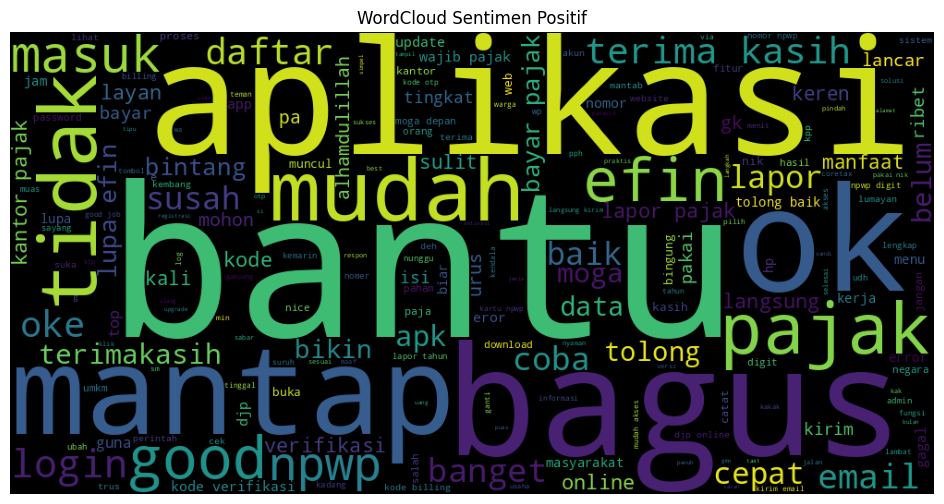

In [35]:
positive_text = ' '.join(
    df[df['sentiment']==1]['clean_text']
)

wordcloud = WordCloud(
    width=1000,
    height=500
).generate(positive_text)

plt.figure(figsize=(15,6))
plt.imshow(wordcloud)
plt.axis('off')
plt.title('WordCloud Sentimen Positif')
plt.show()

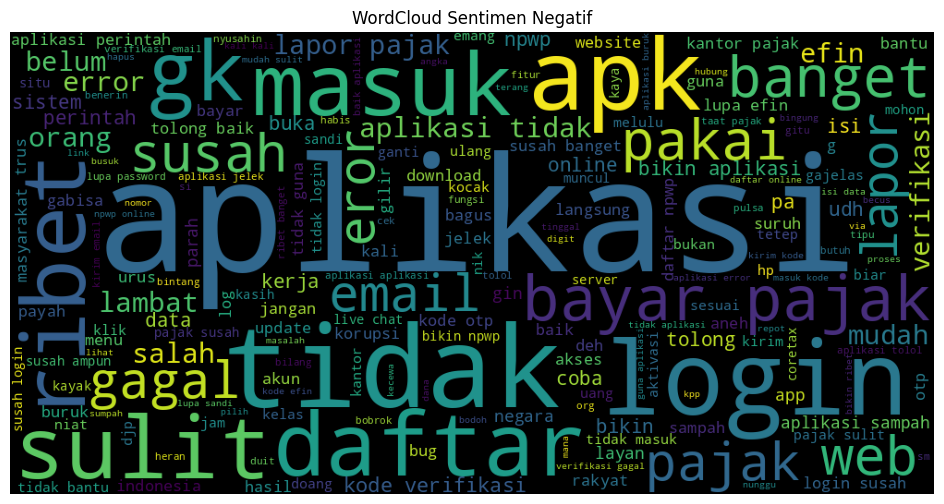

In [36]:
negative_text = ' '.join(
    df[df['sentiment']==0]['clean_text']
)

wordcloud = WordCloud(
    width=1000,
    height=500
).generate(negative_text)

plt.figure(figsize=(15,6))
plt.imshow(wordcloud)
plt.axis('off')
plt.title('WordCloud Sentimen Negatif')
plt.show()

# TF-IDF

In [37]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
max_features=5000,
ngram_range=(1,2)
)

X = tfidf.fit_transform(df['clean_text'])

y = df['sentiment']

TF-IDF digunakan untuk mengubah data teks menjadi data numerik sehingga dapat diproses oleh algoritma machine learning. Setiap kata akan diberikan bobot berdasarkan frekuensi kemunculannya dalam dokumen dan keseluruhan dataset.

# Split Data

In [38]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
X,
y,
test_size=0.2,
random_state=42,
stratify=y
)

Dataset dibagi menjadi:

1. 80% data latih
2. 20% data uji

# Model

Accuracy : 0.8961748633879781
              precision    recall  f1-score   support

           0       0.89      1.00      0.94      1158
           1       0.97      0.52      0.68       306

    accuracy                           0.90      1464
   macro avg       0.93      0.76      0.81      1464
weighted avg       0.90      0.90      0.88      1464



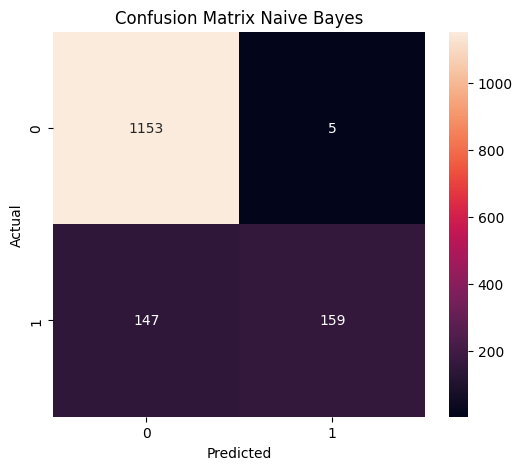

In [39]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
classification_report,
confusion_matrix,
accuracy_score
)

nb = MultinomialNB()

nb.fit(X_train, y_train)

y_pred = nb.predict(X_test)

print("Accuracy :", accuracy_score(y_test, y_pred))

print(classification_report(
y_test,
y_pred
))

cm = confusion_matrix(
y_test,
y_pred
)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

sns.heatmap(
cm,
annot=True,
fmt='d'
)

plt.title("Confusion Matrix Naive Bayes")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()


Berdasarkan hasil pengujian menggunakan algoritma Naive Bayes, diperoleh confusion matrix dengan nilai True Positive (TP) sebesar 4091, True Negative (TN) sebesar 1377, False Positive (FP) sebesar 208, dan False Negative (FN) sebesar 324. Hasil tersebut menunjukkan bahwa model mampu mengklasifikasikan sebagian besar data dengan benar.

Nilai akurasi yang diperoleh sebesar 91,13%, yang menunjukkan bahwa model mampu melakukan klasifikasi sentimen dengan tingkat ketepatan yang tinggi. Selain itu, nilai precision sebesar 95,16% menunjukkan bahwa sebagian besar prediksi sentimen positif yang dihasilkan model sesuai dengan kondisi sebenarnya. Nilai recall sebesar 92,66% menunjukkan bahwa model mampu mengidentifikasi sebagian besar data sentimen positif pada dataset.

Berdasarkan hasil tersebut, dapat disimpulkan bahwa algoritma Naive Bayes memiliki performa yang baik dalam melakukan klasifikasi sentimen pada ulasan pengguna aplikasi Grab.


1. 1377 review negatif berhasil dikenali dengan benar.
2. 4091 review positif berhasil dikenali dengan benar.
3. 208 review negatif keliru dianggap positif.
4. 324 review positif keliru dianggap negatif.

In [40]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[1153    5]
 [ 147  159]]


In [41]:
TN = cm[0][0]  # 1377
FP = cm[0][1]  # 208
FN = cm[1][0]  # 324
TP = cm[1][1]  # 4091

print("TN =", TN)
print("FP =", FP)
print("FN =", FN)
print("TP =", TP)

TN = 1153
FP = 5
FN = 147
TP = 159


# Simpan Model

In [42]:
import joblib

joblib.dump(nb, 'naive_bayes_model.pkl')
joblib.dump(tfidf, 'tfidf.pkl')

['tfidf.pkl']

## Lihat kata yang paling sering muncul

In [43]:
import pandas as pd

feature_names = tfidf.get_feature_names_out()

freq = X.sum(axis=0).A1

word_freq = pd.DataFrame({
    'word': feature_names,
    'score': freq
})

word_freq.sort_values(
    by='score',
    ascending=False
).head(20)

,word,score
225,aplikasi,401.980160
4545,tidak,226.436077
3367,pajak,177.007694
597,bantu,155.687416
2460,login,154.636269
516,bagus,153.054036
4397,susah,148.981054
3265,ok,148.537820
141,apk,128.805623
3778,ribet,128.277334
